In [34]:
#%pip install pandas numpy seaborn matplotlib

In [35]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
price_df = pd.read_csv(r"data/Bakeryprice.csv")


In [ ]:
sales_df = pd.read_csv("data/Bakerysales.csv")

In [38]:
# ==========================================
# DIMENSIONES INICIALES DE LOS DATASETS
# ==========================================

print("Shape prices_df:", price_df.shape)
print("Shape sales_df:", sales_df.shape)

Shape prices_df: (22, 2)
Shape sales_df: (2654, 27)


In [39]:
sales_df.head()




,datetime,day of week,total,place,angbutter,plain bread,jam,americano,croissant,caffe latte,...,gateau chocolat,pandoro,cheese cake,lemon ade,orange pound,wiener,vanila latte,berry ade,tiramisu,merinque cookies
0,2019-07-11 15:35,Thur,23800.0,NaN,1.0,NaN,NaN,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN
1,2019-07-11 16:10,Thur,15800.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
2,2019-07-12 11:49,Fri,58000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2019-07-13 13:19,Sat,14800.0,NaN,1.0,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN
4,2019-07-13 13:22,Sat,15600.0,NaN,2.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [40]:
sales_df.isnull().sum().sort_values(ascending=False)

croque monsieur       2654
mad garlic            2654
tiramisu              2647
lemon ade             2619
merinque cookies      2607
berry ade             2600
cheese cake           2564
milk tea              2517
caffe latte           2461
gateau chocolat       2458
almond croissant      2452
vanila latte          2445
jam                   2434
cacao deep            2331
pandoro               2311
wiener                2299
americano             2242
orange pound          2135
pain au chocolat      2067
croissant             1907
tiramisu croissant    1875
plain bread           1797
angbutter              681
place                  488
day of week            234
total                  234
datetime               233
dtype: int64

In [41]:
sales_df.duplicated().sum()

np.int64(232)

In [42]:
price_df.isnull().sum()

Name     0
price    0
dtype: int64

In [43]:
price_df

,Name,price
0,angbutter,4800
1,plain bread,3500
2,jam,1500
3,ice coffe,4000
4,croissant,3500
5,ice coffe latter,4500
6,tiramisu croissant,4800
7,cacao deep,4000
8,pain au chocolat,3500
9,almond croissant,4000


In [44]:
#analizar null y duplicados en dfprice
price_df.isnull().sum()
price_df.duplicated().sum()


np.int64(0)

In [45]:
sales_df.duplicated().sum()

np.int64(232)

In [46]:
# ==========================================
# CONVERSIÓN ROBUSTA DE DATETIME
# ==========================================

sales_df['datetime'] = pd.to_datetime(
    sales_df['datetime'],
    errors='coerce'
)
# eliminar fechas corruptas convertidas en NaT
sales_df = sales_df.dropna(subset=['datetime'])

sales_df.isnull().sum().sort_values(ascending=False)


croque monsieur       2421
mad garlic            2421
tiramisu              2414
lemon ade             2386
merinque cookies      2374
berry ade             2367
cheese cake           2331
milk tea              2284
caffe latte           2228
gateau chocolat       2225
almond croissant      2219
vanila latte          2212
jam                   2201
cacao deep            2098
pandoro               2078
wiener                2066
americano             2009
orange pound          1902
pain au chocolat      1834
croissant             1674
tiramisu croissant    1642
plain bread           1564
angbutter              448
place                  255
day of week              1
total                    1
datetime                 0
dtype: int64

In [47]:
sales_df['datetime'] = pd.to_datetime(sales_df['datetime'])
sales_df.info()

<class 'pandas.DataFrame'>
Index: 2421 entries, 0 to 2653
Data columns (total 27 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   datetime            2421 non-null   datetime64[us]
 1   day of week         2420 non-null   str           
 2   total               2420 non-null   float64       
 3   place               2166 non-null   str           
 4   angbutter           1973 non-null   float64       
 5   plain bread         857 non-null    float64       
 6   jam                 220 non-null    float64       
 7   americano           412 non-null    float64       
 8   croissant           747 non-null    float64       
 9   caffe latte         193 non-null    float64       
 10  tiramisu croissant  779 non-null    float64       
 11  cacao deep          323 non-null    float64       
 12  pain au chocolat    587 non-null    float64       
 13  almond croissant    202 non-null    float64       
 14  croque m

In [48]:
id_columns = ['datetime', 'day of week', 'total', 'place']
product_columns = [col for col in sales_df.columns if col not in id_columns]

In [49]:
sales_df[product_columns] = sales_df[product_columns].fillna(0)

In [50]:
sales_df.duplicated().sum()

np.int64(0)

In [51]:
sales_long = sales_df.melt(
    id_vars=id_columns,
    value_vars=product_columns,
    var_name='product',
    value_name='quantity'
)

In [52]:
sales_long = sales_long[sales_long['quantity'] > 0]

In [53]:
sales_long.head(20)

,datetime,day of week,total,place,product,quantity
0,2019-07-11 15:35:00,Thur,23800.0,NaN,angbutter,1.0
1,2019-07-11 16:10:00,Thur,15800.0,NaN,angbutter,1.0
3,2019-07-13 13:19:00,Sat,14800.0,NaN,angbutter,1.0
4,2019-07-13 13:22:00,Sat,15600.0,NaN,angbutter,2.0
5,2019-07-13 14:54:00,Sat,15800.0,NaN,angbutter,1.0
6,2019-07-13 15:08:00,Sat,15800.0,NaN,angbutter,1.0
8,2019-07-13 15:23:00,Sat,19100.0,NaN,angbutter,2.0
9,2019-07-13 16:32:00,Sat,22300.0,NaN,angbutter,1.0
10,2019-07-14 11:08:00,Sun,15300.0,NaN,angbutter,1.0
11,2019-07-14 11:15:00,Sun,27600.0,NaN,angbutter,2.0


In [54]:
# ==========================================
# CORRECCIÓN MANUAL DE NOMBRES DE PRODUCTOS
# ==========================================
product_mapping = {
    'ice coffe': 'americano',
    'latte coffee': 'caffe latte',
    'ice milk tea': 'milk tea',
    'valina latte': 'vanilla latte'
}


In [55]:
# ==========================================
# NORMALIZACIÓN DE TEXTO EN PRODUCTOS
# ==========================================

# en ventas
sales_long['product'] = (
    sales_long['product']
    .str.strip()        # elimina espacios
    .str.lower()        # minúsculas
)

# en precios
price_df['Name'] = (
    price_df['Name']
    .str.strip()
    .str.lower()
)

In [56]:
#pip install rapidfuzz 
from rapidfuzz import process

price_products = price_df['Name'].unique()

def match_product(product):
    match, score, _ = process.extractOne(product, price_products)
    return match if score > 80 else None

sales_long['product_matched'] = sales_long['product'].apply(match_product)

In [57]:
df = sales_long.merge(
    price_df,
    left_on='product_matched',
    right_on='Name',
    how='left'
)

In [58]:
df[df['price'].isnull()]

,datetime,day of week,total,place,product,quantity,product_matched,Name,price
3050,2019-07-11 15:35:00,Thur,23800.0,NaN,americano,1.0,NaN,NaN,NaN
3051,2019-07-14 11:15:00,Sun,27600.0,NaN,americano,3.0,NaN,NaN,NaN
3052,2019-07-20 11:35:00,Sat,18800.0,NaN,americano,1.0,NaN,NaN,NaN
3053,2019-07-20 13:56:00,Sat,17800.0,NaN,americano,1.0,NaN,NaN,NaN
3054,2019-07-21 12:12:00,Sun,17800.0,NaN,americano,1.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
4397,2020-04-25 11:42:00,Sat,36600.0,퇴계동,caffe latte,1.0,NaN,NaN,NaN
4398,2020-04-25 13:56:00,Sat,29300.0,동면,caffe latte,2.0,NaN,NaN,NaN
4399,2020-04-27 11:41:00,Mon,19800.0,동면,caffe latte,1.0,NaN,NaN,NaN
4400,2020-05-01 11:32:00,Fri,15000.0,동면,caffe latte,1.0,NaN,NaN,NaN


In [59]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 8285 entries, 0 to 8284
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   datetime         8285 non-null   datetime64[us]
 1   day of week      8285 non-null   str           
 2   total            8285 non-null   float64       
 3   place            7408 non-null   str           
 4   product          8285 non-null   str           
 5   quantity         8285 non-null   float64       
 6   product_matched  7680 non-null   str           
 7   Name             7680 non-null   str           
 8   price            7680 non-null   str           
dtypes: datetime64[us](1), float64(2), str(6)
memory usage: 582.7 KB


,datetime,total,quantity
count,8285,8.285000e+03,8285.000000
mean,2019-12-11 14:57:54.995775,2.260753e+04,1.308389
min,2019-07-11 15:35:00,1.280000e+04,1.000000
25%,2019-09-22 12:08:00,1.600000e+04,1.000000
50%,2019-12-14 13:14:00,1.930000e+04,1.000000
75%,2020-02-27 11:25:00,2.430000e+04,1.000000
max,2020-05-02 14:45:00,1.293000e+06,16.000000
std,NaN,3.520208e+04,0.790994


In [60]:
df.head()

,datetime,day of week,total,place,product,quantity,product_matched,Name,price
0,2019-07-11 15:35:00,Thur,23800.0,NaN,angbutter,1.0,angbutter,angbutter,4800
1,2019-07-11 16:10:00,Thur,15800.0,NaN,angbutter,1.0,angbutter,angbutter,4800
2,2019-07-13 13:19:00,Sat,14800.0,NaN,angbutter,1.0,angbutter,angbutter,4800
3,2019-07-13 13:22:00,Sat,15600.0,NaN,angbutter,2.0,angbutter,angbutter,4800
4,2019-07-13 14:54:00,Sat,15800.0,NaN,angbutter,1.0,angbutter,angbutter,4800


In [61]:
# ==========================================
# VALIDACIÓN DE PRODUCTOS SIN PRECIO
# ==========================================

missing_prices = df['price'].isnull().sum()

print("Productos sin precio:", missing_prices)

# visualizar productos problemáticos
df[df['price'].isnull()]

Productos sin precio: 605


,datetime,day of week,total,place,product,quantity,product_matched,Name,price
3050,2019-07-11 15:35:00,Thur,23800.0,NaN,americano,1.0,NaN,NaN,NaN
3051,2019-07-14 11:15:00,Sun,27600.0,NaN,americano,3.0,NaN,NaN,NaN
3052,2019-07-20 11:35:00,Sat,18800.0,NaN,americano,1.0,NaN,NaN,NaN
3053,2019-07-20 13:56:00,Sat,17800.0,NaN,americano,1.0,NaN,NaN,NaN
3054,2019-07-21 12:12:00,Sun,17800.0,NaN,americano,1.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
4397,2020-04-25 11:42:00,Sat,36600.0,퇴계동,caffe latte,1.0,NaN,NaN,NaN
4398,2020-04-25 13:56:00,Sat,29300.0,동면,caffe latte,2.0,NaN,NaN,NaN
4399,2020-04-27 11:41:00,Mon,19800.0,동면,caffe latte,1.0,NaN,NaN,NaN
4400,2020-05-01 11:32:00,Fri,15000.0,동면,caffe latte,1.0,NaN,NaN,NaN


In [62]:
# ==========================================
# IDENTIFICAR PRODUCTOS SIN PRECIO
# ==========================================


df['product'] = df['product'].replace(product_mapping)
missing_products = df[df['price'].isnull()]['product'].unique()


In [63]:
missing_products = df[df['price'].isnull()]['product'].unique()

print("Productos sin match tras normalización:")
print(missing_products)

Productos sin match tras normalización:
<StringArray>
['americano', 'caffe latte']
Length: 2, dtype: str


In [64]:
# ==========================================
# CUANTIFICAR PRODUCTOS SIN MATCH
# ==========================================

missing_products = df[df['price'].isnull()]['product']

print("Filas sin precio:", len(missing_products))
print("Productos únicos sin precio:", missing_products.nunique())

Filas sin precio: 605
Productos únicos sin precio: 2


In [65]:
# ==========================================
# FRECUENCIA DE PRODUCTOS SIN MATCH
# ==========================================

missing_counts = missing_products.value_counts()

missing_counts.head(20)

product
americano      412
caffe latte    193
Name: count, dtype: int64

In [66]:
# ==========================================
# COMPARACIÓN ENTRE PRODUCTOS
# ==========================================

sales_df = set(sales_long['product'].unique())
products_prices = set(price_df['Name'].unique())

only_in_sales = sales_df - products_prices
only_in_prices = products_prices - sales_df

print("Productos en ventas pero NO en precios:", len(only_in_sales))
print("Productos en precios pero NO en ventas:", len(only_in_prices))

list(only_in_sales)[:20]

Productos en ventas pero NO en precios: 4
Productos en precios pero NO en ventas: 5


['caffe latte', 'americano', 'milk tea', 'vanila latte']

In [67]:
#pip install rapidfuzz

In [68]:
missing_prices = df['price'].isnull().sum()

print("Precios faltantes tras fuzzy matching:", missing_prices)

Precios faltantes tras fuzzy matching: 605


In [69]:
# ==========================================
# CREANDO DATASET LIMPIO (SOLO PRODUCTOS CON PRECIO)
# ==========================================

clean_df = df.dropna(subset=['price']).copy()

In [70]:
# ==========================================
# GUARDADO DATASET CON ERRORES (PARA AUDITORÍA)
# ==========================================

missing_price_df = df[df['price'].isnull()].copy()

In [71]:
# ==========================================
# IMPACTO DE LA LIMPIEZA
# ==========================================

initial_rows = len(df)
clean_rows = len(clean_df)

print("Filas originales:", initial_rows)
print("Filas limpias:", clean_rows)
print("Filas eliminadas:", initial_rows - clean_rows)

print("Porcentaje eliminado:", 
      round((initial_rows - clean_rows) / initial_rows * 100, 2), "%")

Filas originales: 8285
Filas limpias: 7680
Filas eliminadas: 605
Porcentaje eliminado: 7.3 %


In [72]:
# ==========================================
# VALIDACIÓN FINAL DATASET LIMPIO
# ==========================================

print(clean_df['price'].isnull().sum()) 

0


In [73]:
# ==========================================
# CÁLCULO DE REVENUE POR LÍNEA
# ==========================================

# Ensure the 'price' column is numeric
clean_df['price'] = pd.to_numeric(clean_df['price'], errors='coerce')

# Calculate revenue per line
clean_df['line_revenue'] = clean_df['quantity'] * clean_df['price']

In [74]:
# ==========================================
# KPIs GENERALES
# Revenue → cuánto dinero genera el negocio
# Units → volumen operativo
# Transactions → demanda
# ==========================================

total_revenue = clean_df['line_revenue'].sum()
total_units = clean_df['quantity'].sum()
total_transactions = clean_df['datetime'].nunique()

print("Total Revenue:", round(total_revenue, 2))
print("Total Units Sold:", total_units)
print("Total Transactions:", total_transactions)

Total Revenue: 41875700.0
Total Units Sold: 10113.0
Total Transactions: 2359


In [75]:
# ==========================================
# FUNCIÓN DE KPIs GENERALES
# ==========================================

def compute_kpis(df):
    total_revenue = df['line_revenue'].sum()
    total_units = df['quantity'].sum()
    total_transactions = df['datetime'].nunique()
    
    avg_ticket = total_revenue / total_transactions if total_transactions > 0 else 0
    
    return {
        "total_revenue": total_revenue,
        "total_units": total_units,
        "total_transactions": total_transactions,
        "avg_ticket": avg_ticket
    }

kpis = compute_kpis(clean_df)
kpis

{'total_revenue': np.float64(41875700.0),
 'total_units': np.float64(10113.0),
 'total_transactions': 2359,
 'avg_ticket': np.float64(17751.462484103435)}

In [76]:
# ==========================================
# TICKET MEDIO
# ==========================================

revenue_per_ticket = clean_df.groupby('datetime')['line_revenue'].sum()

average_ticket = revenue_per_ticket.mean()

print("Average Ticket:", round(average_ticket, 2))

Average Ticket: 17751.46


In [77]:
# ==========================================
# PERFORMANCE POR PRODUCTO
# Ranking de productos
# Volumen vs dinero
# ==========================================

product_performance = clean_df.groupby('product').agg({
    'quantity': 'sum',
    'line_revenue': 'sum'
}).sort_values('line_revenue', ascending=False)

product_performance.head(10)

,quantity,line_revenue
product,,
angbutter,3229.0,15499200.0
tiramisu croissant,945.0,4536000.0
croissant,1049.0,3671500.0
plain bread,1028.0,3598000.0
orange pound,566.0,2547000.0
pain au chocolat,726.0,2541000.0
pandoro,394.0,1773000.0
cacao deep,364.0,1456000.0
wiener,476.0,1190000.0


In [78]:
# ==========================================
# MÉTRICAS DERIVADAS POR PRODUCTO
# avg_price → consistencia pricing
# revenue_share → dependencia del negocio
# ==========================================

product_performance['avg_price'] = (
    product_performance['line_revenue'] / product_performance['quantity']
)

product_performance['revenue_share'] = (
    product_performance['line_revenue'] / total_revenue
)

product_performance.head(10)

,quantity,line_revenue,avg_price,revenue_share
product,,,,
angbutter,3229.0,15499200.0,4800.0,0.370124
tiramisu croissant,945.0,4536000.0,4800.0,0.108321
croissant,1049.0,3671500.0,3500.0,0.087676
plain bread,1028.0,3598000.0,3500.0,0.085921
orange pound,566.0,2547000.0,4500.0,0.060823
pain au chocolat,726.0,2541000.0,3500.0,0.060680
pandoro,394.0,1773000.0,4500.0,0.042340
cacao deep,364.0,1456000.0,4000.0,0.034770
wiener,476.0,1190000.0,2500.0,0.028417


In [79]:
# ==========================================
# ANÁLISIS PARETO
# El 20% de productos que generan el 80% del revenue
# ==========================================

product_performance = product_performance.sort_values('line_revenue', ascending=False)

product_performance['cumulative_revenue'] = product_performance['line_revenue'].cumsum()
product_performance['cumulative_share'] = (
    product_performance['cumulative_revenue'] / total_revenue
)

product_performance.head(15)

,quantity,line_revenue,avg_price,revenue_share,cumulative_revenue,cumulative_share
product,,,,,,
angbutter,3229.0,15499200.0,4800.0,0.370124,15499200.0,0.370124
tiramisu croissant,945.0,4536000.0,4800.0,0.108321,20035200.0,0.478445
croissant,1049.0,3671500.0,3500.0,0.087676,23706700.0,0.566121
plain bread,1028.0,3598000.0,3500.0,0.085921,27304700.0,0.652042
orange pound,566.0,2547000.0,4500.0,0.060823,29851700.0,0.712865
pain au chocolat,726.0,2541000.0,3500.0,0.060680,32392700.0,0.773544
pandoro,394.0,1773000.0,4500.0,0.042340,34165700.0,0.815884
cacao deep,364.0,1456000.0,4000.0,0.034770,35621700.0,0.850653
wiener,476.0,1190000.0,2500.0,0.028417,36811700.0,0.879071


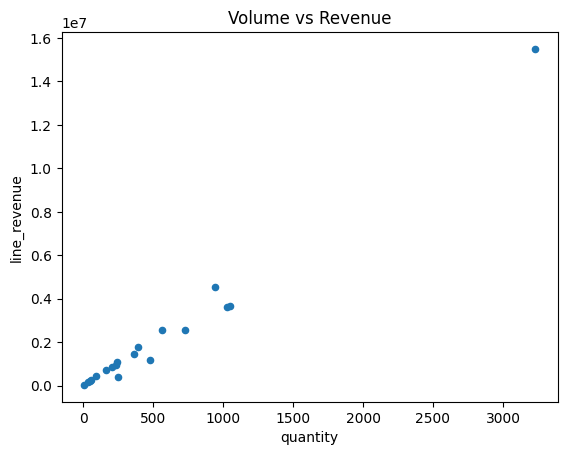

In [80]:
# ==========================================
# VOLUMEN VS REVENUE

# Clasificas productos en:
# alto volumen / bajo valor
# bajo volumen / alto valor
# estrellas
# irrelevantes
# ==========================================

product_performance[['quantity', 'line_revenue']].plot(kind='scatter', x='quantity', y='line_revenue')

plt.title("Volume vs Revenue")
plt.show()

In [81]:
# ==========================================
# FEATURE ENGINEERING TEMPORAL
# ==========================================

clean_df['hour'] = clean_df['datetime'].dt.hour
clean_df['weekday'] = clean_df['datetime'].dt.day_name()

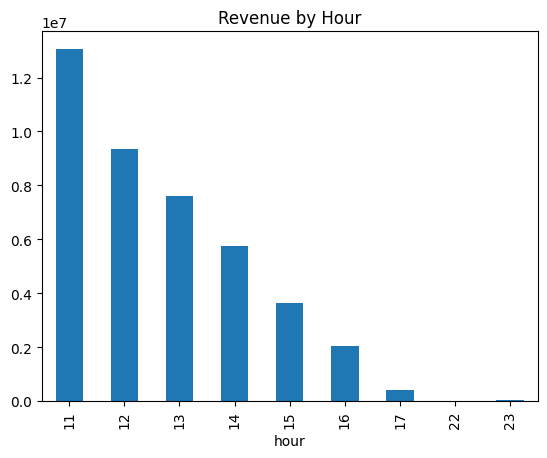

In [82]:
# ==========================================
# REVENUE POR HORA
# ==========================================

hourly_revenue = clean_df.groupby('hour')['line_revenue'].sum()

hourly_revenue.plot(kind='bar')
plt.title("Revenue by Hour")
plt.show()

In [83]:
# ==========================================
# VALIDACIÓN FINAL DE CONSISTENCIA
# ==========================================

calculated_total = clean_df['line_revenue'].sum()
original_total = clean_df['total'].sum()

print("Calculated total:", round(calculated_total, 2))
print("Original total:", round(original_total, 2))
print("Difference:", round(original_total - calculated_total, 2))

Calculated total: 41875700.0
Original total: 174713000.0
Difference: 132837300.0


In [84]:
# ==========================================
# EXPORTACIÓN PARA POWER BI
# ==========================================

clean_df.to_csv("clean_bakery_data.csv", index=False)

In [85]:
# ==========================================
# INSIGHT: PARETO DE PRODUCTOS
# ==========================================

def pareto_analysis(df):
    product_perf = df.groupby('product')['line_revenue'].sum().sort_values(ascending=False)
    
    cumulative = product_perf.cumsum() / product_perf.sum()
    
    pareto_df = pd.DataFrame({
        'revenue': product_perf,
        'cumulative_share': cumulative
    })
    
    top_80 = pareto_df[pareto_df['cumulative_share'] <= 0.8]
    
    print(f"Productos que generan el 80% del revenue: {len(top_80)}")
    
    return pareto_df

pareto_df = pareto_analysis(clean_df)
pareto_df.head(10)

Productos que generan el 80% del revenue: 6


,revenue,cumulative_share
product,,
angbutter,15499200.0,0.370124
tiramisu croissant,4536000.0,0.478445
croissant,3671500.0,0.566121
plain bread,3598000.0,0.652042
orange pound,2547000.0,0.712865
pain au chocolat,2541000.0,0.773544
pandoro,1773000.0,0.815884
cacao deep,1456000.0,0.850653
wiener,1190000.0,0.879071


In [86]:
# ==========================================
# INSIGHT: CLASIFICACIÓN DE PRODUCTOS
# ==========================================

def product_segmentation(df):
    perf = df.groupby('product').agg({
        'quantity': 'sum',
        'line_revenue': 'sum'
    })
    
    perf['avg_price'] = perf['line_revenue'] / perf['quantity']
    
    # thresholds
    q_threshold = perf['quantity'].median()
    r_threshold = perf['line_revenue'].median()
    
    def classify(row):
        if row['quantity'] >= q_threshold and row['line_revenue'] >= r_threshold:
            return 'STAR'
        elif row['quantity'] >= q_threshold:
            return 'VOLUME DRIVER'
        elif row['line_revenue'] >= r_threshold:
            return 'PREMIUM'
        else:
            return 'LOW PERFORMER'
    
    perf['category'] = perf.apply(classify, axis=1)
    
    return perf

product_segments = product_segmentation(clean_df)
product_segments.head(10)

,quantity,line_revenue,avg_price,category
product,,,,
almond croissant,235.0,940000.0,4000.0,LOW PERFORMER
angbutter,3229.0,15499200.0,4800.0,STAR
berry ade,55.0,247500.0,4500.0,LOW PERFORMER
cacao deep,364.0,1456000.0,4000.0,STAR
cheese cake,92.0,460000.0,5000.0,LOW PERFORMER
croissant,1049.0,3671500.0,3500.0,STAR
gateau chocolat,210.0,840000.0,4000.0,LOW PERFORMER
jam,249.0,373500.0,1500.0,VOLUME DRIVER
lemon ade,38.0,171000.0,4500.0,LOW PERFORMER


In [87]:
# ==========================================
# INSIGHT: HORAS PICO
# ==========================================

def peak_hours(df):
    hourly = df.groupby('hour')['line_revenue'].sum().sort_values(ascending=False)
    
    top_hours = hourly.head(3)
    
    print("Horas pico:")
    print(top_hours)
    
    return hourly

hourly_revenue = peak_hours(clean_df)

Horas pico:
hour
11    13059700.0
12     9333200.0
13     7593800.0
Name: line_revenue, dtype: float64


In [88]:
# ==========================================
# INSIGHT: PRODUCTOS CON BAJO PRECIO MEDIO
# ==========================================

def upsell_opportunities(df):
    perf = df.groupby('product').agg({
        'quantity': 'sum',
        'line_revenue': 'sum'
    })
    
    perf['avg_price'] = perf['line_revenue'] / perf['quantity']
    
    low_price = perf.sort_values('avg_price').head(10)
    
    print("Productos con potencial de upselling:")
    return low_price

upsell_df = upsell_opportunities(clean_df)
upsell_df

Productos con potencial de upselling:


,quantity,line_revenue,avg_price
product,,,
jam,249.0,373500.0,1500.0
wiener,476.0,1190000.0,2500.0
pain au chocolat,726.0,2541000.0,3500.0
croissant,1049.0,3671500.0,3500.0
plain bread,1028.0,3598000.0,3500.0
gateau chocolat,210.0,840000.0,4000.0
almond croissant,235.0,940000.0,4000.0
merinque cookies,49.0,196000.0,4000.0
cacao deep,364.0,1456000.0,4000.0


In [89]:
# ==========================================
# GENERADOR DE INSIGHTS TEXTUALES
# ==========================================

def generate_insights(df):
    kpis = compute_kpis(df)
    pareto = pareto_analysis(df)
    
    insights = []
    
    insights.append(f"El revenue total es {round(kpis['total_revenue'],2)}")
    insights.append(f"El ticket medio es {round(kpis['avg_ticket'],2)}")
    
    top_product = df.groupby('product')['line_revenue'].sum().idxmax()
    insights.append(f"El producto más importante es {top_product}")
    
    return insights

generate_insights(clean_df)

Productos que generan el 80% del revenue: 6


['El revenue total es 41875700.0',
 'El ticket medio es 17751.46',
 'El producto más importante es angbutter']